# 01 Expert Training

Train one expert per cluster and run sanity checks from the implementation plan.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / "moe_bandit").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'moe_bandit'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from moe_bandit.data import generate_synthetic_data
from moe_bandit.experts import train_experts, expert_reward_matrix


In [20]:
# Default config
K = 4
d = 4
cluster_sep = 1.5
cluster_std = 1.0
seed_train_data = 101
seed_train_experts = 202
n_train_per_cluster = 2000
n_train_total = K * n_train_per_cluster
contamination = 0.05

X_train, y_train, cluster_train = generate_synthetic_data(
    n_samples=n_train_total,
    K=K,
    d=d,
    cluster_sep=cluster_sep,
    cluster_std=cluster_std,
    seed=seed_train_data,
)

experts = train_experts(
    X_train=X_train,
    y_train=y_train,
    cluster_id_train=cluster_train,
    K=K,
    d=d,
    epochs=30,
    lr=1e-3,
    batch_size=64,
    seed=seed_train_experts,
    contamination=contamination,
)

print('trained experts:', len(experts))
print('contamination:', contamination)


trained experts: 4
contamination: 0.05


In [21]:
# Per-expert accuracy on own-cluster and other-cluster points
own_acc = []
other_acc = []

with torch.no_grad():
    for i, expert in enumerate(experts):
        expert_device = next(expert.parameters()).device
        X_t = torch.as_tensor(X_train, dtype=torch.float32, device=expert_device)
        logits = expert(X_t)
        preds = logits.argmax(dim=1).cpu().numpy()

        own_mask = cluster_train == i
        own = float((preds[own_mask] == y_train[own_mask]).mean())
        own_acc.append(own)

        other_mask = ~own_mask
        other = float((preds[other_mask] == y_train[other_mask]).mean())
        other_acc.append(other)

for i in range(K):
    print(f'expert {i}: own_cluster_acc={own_acc[i]:.3f}, other_cluster_acc={other_acc[i]:.3f}')

mean_own = float(np.mean(own_acc))
mean_other = float(np.mean(other_acc))
print('mean own-cluster accuracy:', mean_own)
print('mean other-cluster accuracy:', mean_other, '(chance ~', 1.0 / K, ')')

# Sanity ranges for contamination=0.2 regime.
assert mean_own >= 0.85, 'own-cluster accuracy unexpectedly low'
assert mean_other > 0.0, 'other-cluster accuracy should be above zero with contamination'


expert 0: own_cluster_acc=0.997, other_cluster_acc=0.220
expert 1: own_cluster_acc=0.997, other_cluster_acc=0.119
expert 2: own_cluster_acc=0.994, other_cluster_acc=0.208
expert 3: own_cluster_acc=0.997, other_cluster_acc=0.196
mean own-cluster accuracy: 0.9962262280736975
mean other-cluster accuracy: 0.18556797493429833 (chance ~ 0.25 )


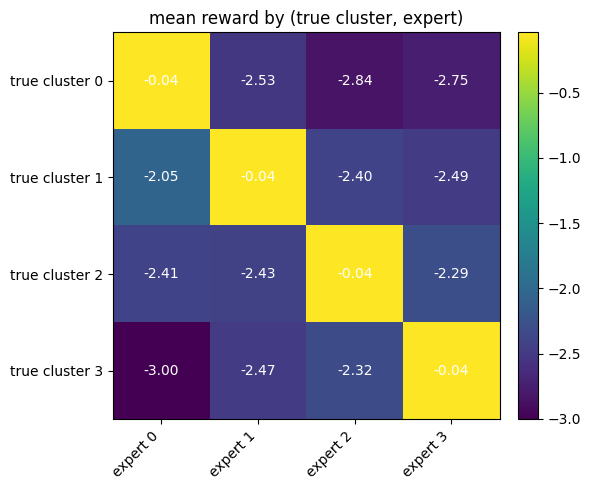

In [22]:
# Reward matrix and grouped heatmap sanity check
R = expert_reward_matrix(experts=experts, X=X_train, y=y_train, clip_eps=1e-3)
mean_reward_by_cluster = np.vstack([R[cluster_train == i].mean(axis=0) for i in range(K)])

plt.figure(figsize=(6, 5))
im = plt.imshow(mean_reward_by_cluster, cmap='viridis')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(K), [f'expert {i}' for i in range(K)], rotation=45, ha='right')
plt.yticks(np.arange(K), [f'true cluster {i}' for i in range(K)])
plt.title('mean reward by (true cluster, expert)')
for i in range(K):
    for j in range(K):
        plt.text(j, i, f'{mean_reward_by_cluster[i, j]:.2f}', ha='center', va='center', color='white')
plt.tight_layout()
plt.show()


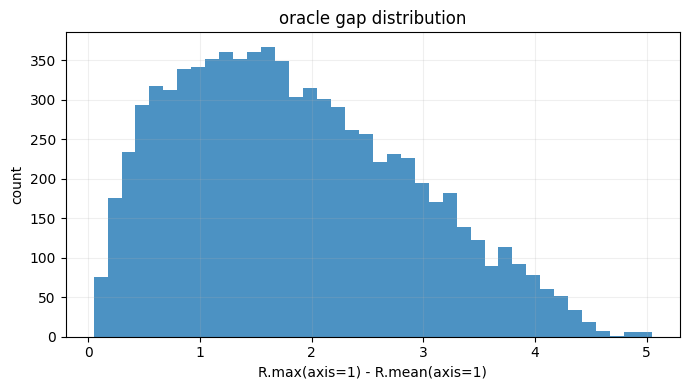

oracle gap mean: 1.8450953463153819
oracle gap p10/p50/p90: [0.55955143 1.7138354  3.32187654]


In [23]:
# Oracle gap distribution
oracle_gap = R.max(axis=1) - R.mean(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(oracle_gap, bins=40, alpha=0.8)
plt.xlabel('R.max(axis=1) - R.mean(axis=1)')
plt.ylabel('count')
plt.title('oracle gap distribution')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('oracle gap mean:', oracle_gap.mean())
print('oracle gap p10/p50/p90:', np.percentile(oracle_gap, [10, 50, 90]))
